In [33]:
import ctypes
import numpy as np
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from data_charge import load_images_from_mongodb
from prepar_data import preprocess_for_rust, transform
import matplotlib.pyplot as plt
import math

In [34]:
# Charger la bibliothèque Rust
lib = ctypes.CDLL("../target/release/mymodel.dll")

# Spécifier les types
lib.create_rbfn_multiclass_model.argtypes = [ctypes.c_double, ctypes.c_double, ctypes.c_size_t, ctypes.c_size_t]
lib.create_rbfn_multiclass_model.restype = ctypes.c_void_p

lib.train_rbfn_model_auto.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_size_t, ctypes.c_size_t, ctypes.c_size_t
]

lib.predict_rbfn_model.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.c_size_t]
lib.predict_rbfn_model.restype = ctypes.c_double


In [35]:
# --- Charger les données depuis MongoDB ---
images, labels = load_images_from_mongodb()  # récupère toutes les images

# --- Séparer en train/test (80% / 20%) ---
images_train, images_test, labels_train, labels_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

# --- Prétraitement ---
X_train, Y_train, label_encoder = preprocess_for_rust(images_train, labels_train)
X_test, Y_test, _ = preprocess_for_rust(images_test, labels_test)

n_train, n_features = X_train.shape
n_outputs = Y_train.shape[1]

In [36]:
# --- Créer le modèle RBFN ---
model_ptr = lib.create_rbfn_multiclass_model(1.0, 0.01, 100, n_outputs)

# --- Entraîner le modèle ---
x_train_ptr = X_train.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
y_train_ptr = Y_train.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

lib.train_rbfn_model_auto(model_ptr, x_train_ptr, y_train_ptr, n_train, n_features, n_outputs)


1

In [37]:
# --- Fonction de prédiction ---
def predict_image(model_ptr, image):
    x = transform(image).numpy().flatten().astype(np.float64)
    x_ptr = x.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    pred = int(lib.predict_rbfn_model(model_ptr, x_ptr, x.shape[0]))
    return label_encoder.inverse_transform([pred])[0]

In [38]:
# --- Évaluation sur le test set ---
y_pred = [predict_image(model_ptr, img) for img in images_test]
# --- Résultat ---
print("✅ Accuracy sur données de test :", accuracy_score(labels_test, y_pred))

✅ Accuracy sur données de test : 0.729064039408867


In [39]:

def afficher_toutes_les_predictions(images, labels, model_ptr):
    n = len(images)  # nombre total d’images à afficher
    cols = 10        # nombre d’images par ligne
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 2, rows * 2))

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.axis('off')

        pred = predict_image(model_ptr, images[i])
        true = labels[i]

        color = "green" if pred == true else "red"
        plt.title(f"P: {pred}\nR: {true}", fontsize=8, color=color)

    plt.tight_layout()
    plt.show()


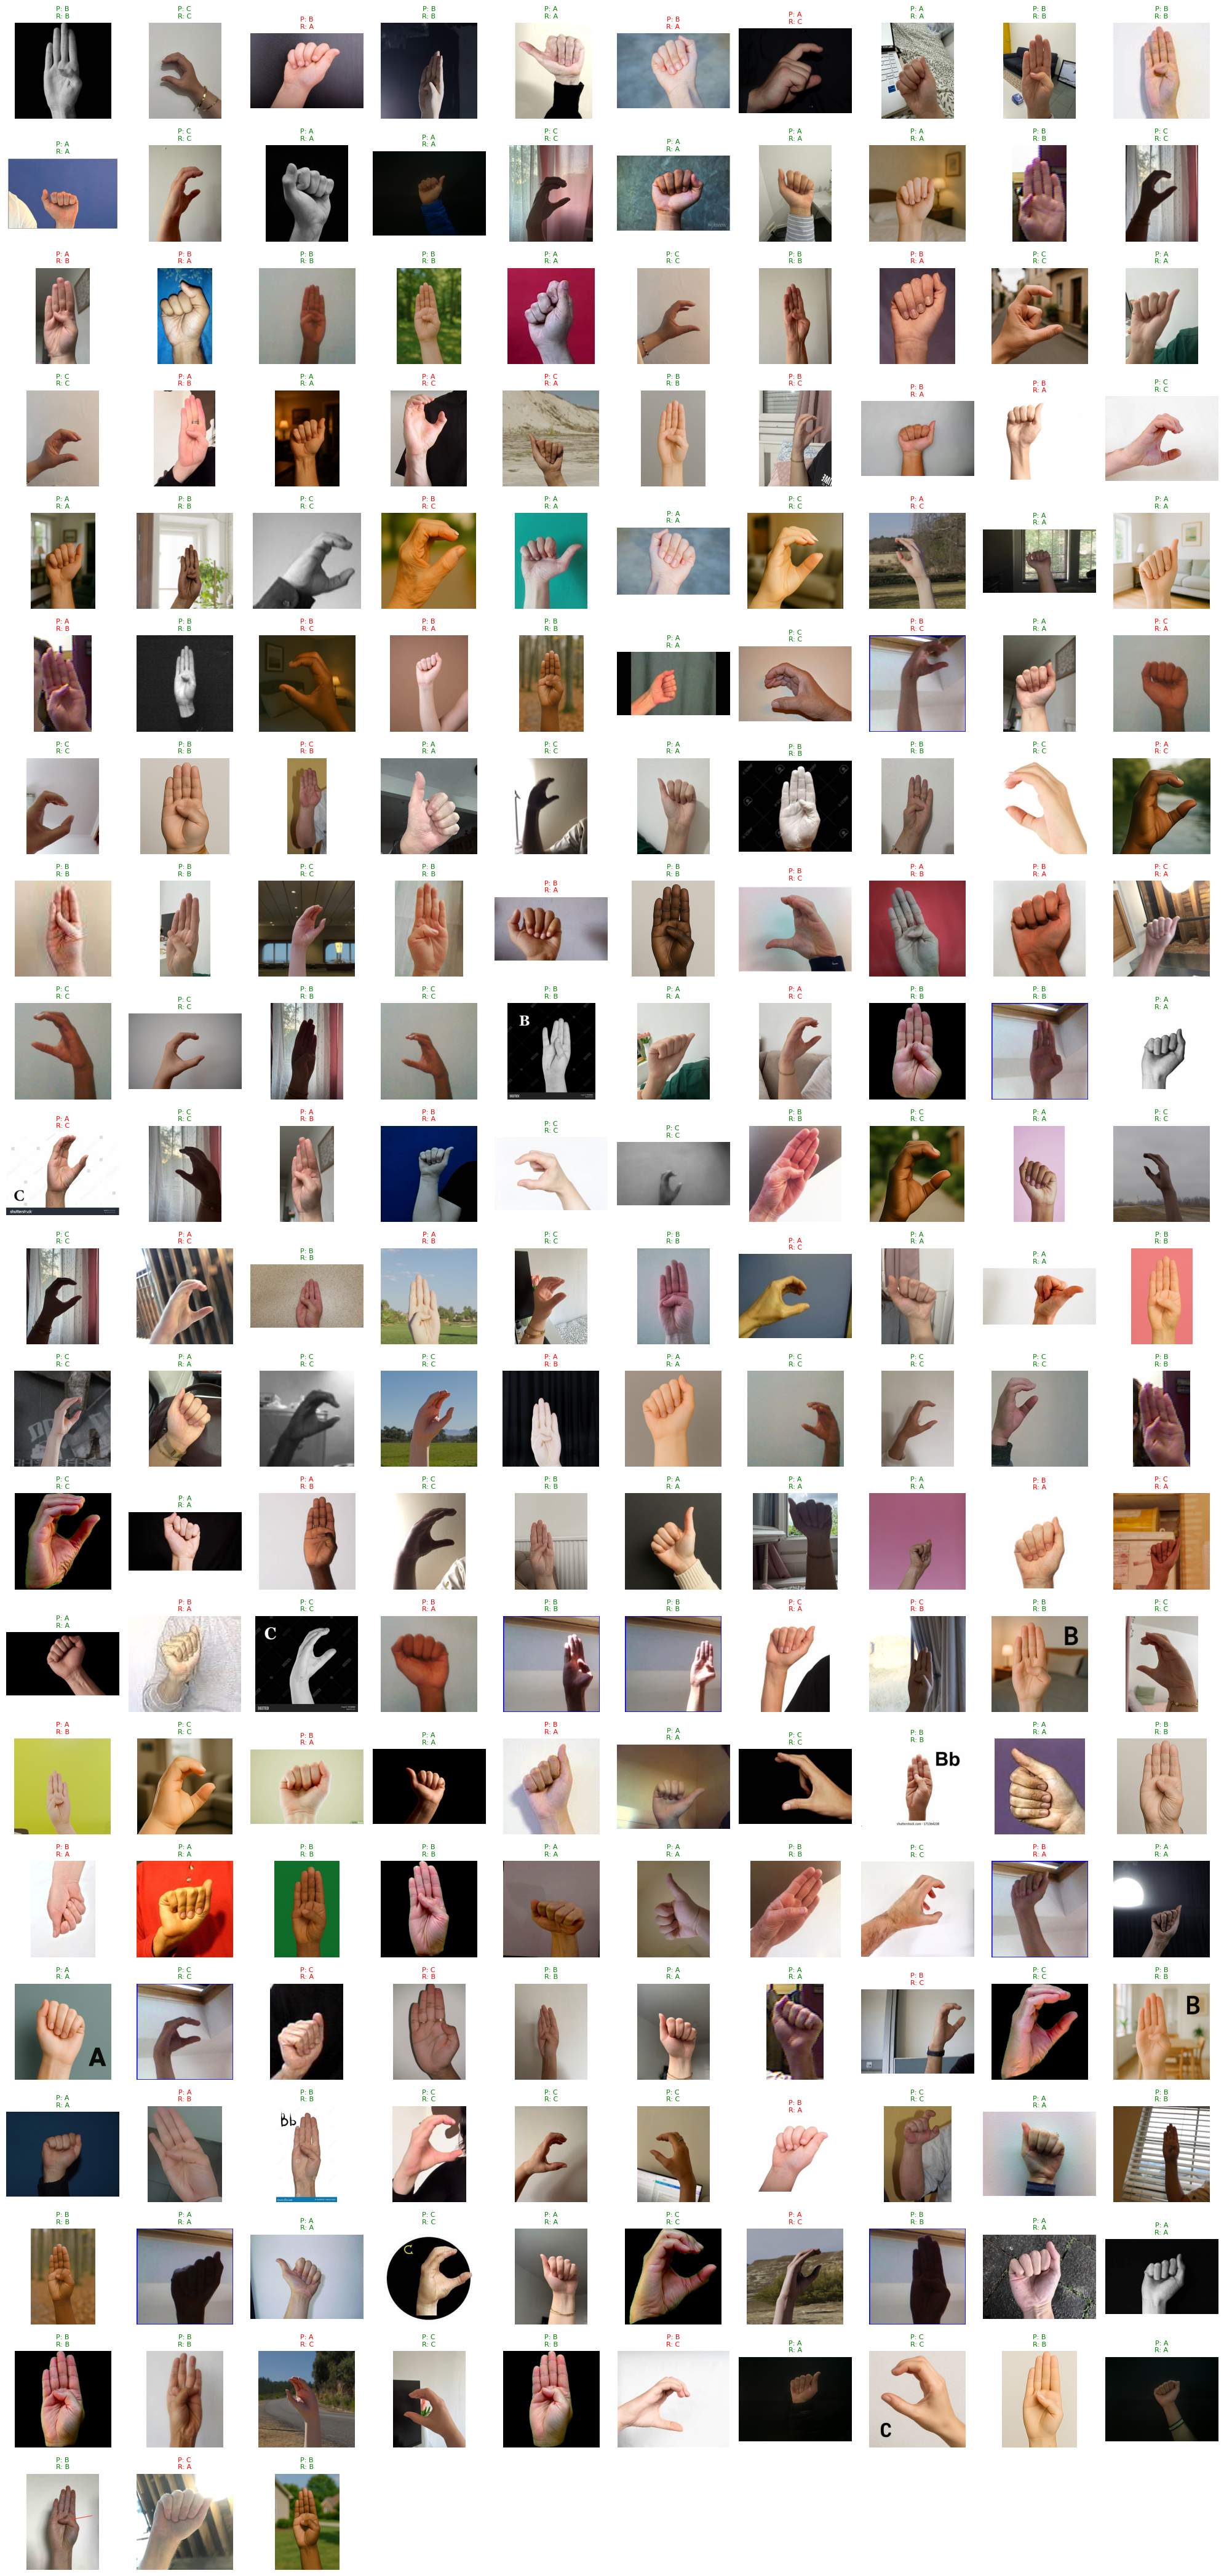

In [40]:
afficher_toutes_les_predictions(images_test, labels_test, model_ptr)
